In [1]:
import sys
from pathlib import Path
import numpy as np
import torch
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, DataCollatorWithPadding

# Setup paths (basato sul tuo script precedente)
ROOT = Path.cwd().resolve().parent
if str(ROOT / "src") not in sys.path:
    sys.path.append(str(ROOT / "src"))

from project_paths import get_paths
paths = get_paths(ROOT)
DATA_DIR = paths.data_processed
CKPT_DIR = paths.checkpoints

print("ROOT:", ROOT)
print("DATA_DIR:", DATA_DIR)
print("CKPT_DIR:", CKPT_DIR)

c:\Users\cola0\anaconda3\envs\nlp-project\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ROOT: C:\Users\cola0\Desktop\nlp.project-colangelo-2526
DATA_DIR: C:\Users\cola0\Desktop\nlp.project-colangelo-2526\data\processed
CKPT_DIR: C:\Users\cola0\Desktop\nlp.project-colangelo-2526\checkpoints


In [2]:
# === Checkpoint paths ===
# Teacher fine-tuned
teacher_path = CKPT_DIR / "bert_teacher_finetuned" / "checkpoint-18000"

# IMPORTANT:
# Per la fase 1 NON usare 'student_base_final' (salva solo il backbone HF).
# Devi usare un checkpoint del Trainer (checkpoint-xxxxx) che contiene anche i pesi di 'fit_dense'.
phase1_ckpt_path = CKPT_DIR / "tinybert_phase1" / "checkpoint-57856"  # <-- ultimo checkpoint
student_core_path = CKPT_DIR / "tinybert_phase1" / "student_base_final"

# (Opzionale) student fase 2, se vuoi confrontare anche quello
student_phase2_path = CKPT_DIR / "tinybert_phase2" / "checkpoint-13000"

print("Teacher:", teacher_path)
print("Phase1 ckpt (con fit_dense):", phase1_ckpt_path)
print("Student phase2 (opzionale):", student_phase2_path)

assert teacher_path.exists(), f"Non esiste: {teacher_path}"
assert phase1_ckpt_path.exists(), f"Non esiste: {phase1_ckpt_path}"


Teacher: C:\Users\cola0\Desktop\nlp.project-colangelo-2526\checkpoints\bert_teacher_finetuned\checkpoint-18000
Phase1 ckpt (con fit_dense): C:\Users\cola0\Desktop\nlp.project-colangelo-2526\checkpoints\tinybert_phase1\checkpoint-57856
Student phase2 (opzionale): C:\Users\cola0\Desktop\nlp.project-colangelo-2526\checkpoints\tinybert_phase2\checkpoint-13000


## Plot 3: PCA only

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased", use_fast=True)

teacher = AutoModelForSequenceClassification.from_pretrained(teacher_path).to(device).eval()

# core HF (student backbone) dal checkpoint fase 1
student_core = AutoModelForSequenceClassification.from_pretrained(phase1_ckpt_path).to(device).eval()


Device: cuda


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at C:\Users\cola0\Desktop\nlp.project-colangelo-2526\checkpoints\tinybert_phase1\checkpoint-57856 and are newly initialized: ['bert.embeddings.LayerNorm.bias', 'bert.embeddings.LayerNorm.weight', 'bert.embeddings.position_embeddings.weight', 'bert.embeddings.token_type_embeddings.weight', 'bert.embeddings.word_embeddings.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.dense.bias', 'bert.encoder.layer.0.attention.output.dense.weight', 'bert.encoder.layer.0.attention.self.key.bias', 'bert.encoder.layer.0.attention.self.key.weight', 'bert.encoder.layer.0.attention.self.query.bias', 'bert.encoder.layer.0.attention.self.query.weight', 'bert.encoder.layer.0.attention.self.value.bias', 'bert.encoder.layer.0.attention.self.value.weight', 'bert.encoder.layer.0.intermediate.dense.bias', 'bert

In [4]:
import torch
from safetensors.torch import load_file
from transformers import AutoModelForSequenceClassification
from distillation import TinyBERTPhase1

device = "cuda" if torch.cuda.is_available() else "cpu"

# path
#student_core_path = "checkpoints/tinybert_phase1/student_base_final"     # ha config 312
#phase1_ckpt_path   = "checkpoints/tinybert_phase1/checkpoint-57856"      # ha wrapper weights incl fit_dense

# 1) Crea core corretto (hidden_size=312)
student_core = AutoModelForSequenceClassification.from_pretrained(student_core_path).to(device).eval()

# 2) Wrappa
student = TinyBERTPhase1(student_core).to(device).eval()

# 3) Carica state dict del trainer checkpoint, ma:
#    - dentro ci sono chiavi "student.*" e "fit_dense.*"
sd = load_file(f"{phase1_ckpt_path}/model.safetensors")

# 4) Carica direttamente: deve andare senza mismatch ora
missing, unexpected = student.load_state_dict(sd, strict=False)

print("Missing fit_dense keys:", [k for k in missing if "fit_dense" in k])
print("Unexpected keys (sample):", unexpected[:15])

Missing fit_dense keys: []
Unexpected keys (sample): []


In [5]:
mapping = [0, 3, 6, 9, 12]
student_last_idx = 4
teacher_last_idx = 12

def mean_pool(hidden, attention_mask):
    # hidden: [1,L,H], attention_mask: [1,L]
    mask = attention_mask.unsqueeze(-1).to(hidden.dtype)  # [1,L,1]
    summed = (hidden * mask).sum(dim=1)
    denom = mask.sum(dim=1).clamp(min=1.0)
    return summed / denom  # [1,H]

@torch.no_grad()
def collect_reps(test_ds, n_samples=2000, seed=0, pooling="mean"):
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(test_ds), size=min(n_samples, len(test_ds)), replace=False)

    T_vecs, S_vecs, y = [], [], []

    for i in idx:
        ex = test_ds[i]
        input_ids = torch.tensor(ex["input_ids"]).unsqueeze(0).to(device)
        attention_mask = torch.tensor(ex["attention_mask"]).unsqueeze(0).to(device)
        token_type_ids = torch.tensor(ex["token_type_ids"]).unsqueeze(0).to(device) if "token_type_ids" in ex else None

        t_out = teacher(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
            output_hidden_states=True,
            return_dict=True
        )
        s_out = student(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
        )

        # teacher hidden: len=13, idx 12 = last layer
        t_h = t_out.hidden_states[teacher_last_idx]  # [1,L,768]

        # student hidden: len=5, idx 4 = last layer (312) -> proiezione in 768 con fit_dense addestrata
        s_h = s_out.hidden_states[student_last_idx]              # [1,L,312]
        s_proj = student.fit_dense[student_last_idx](s_h)        # [1,L,768]

        if pooling == "cls":
            t_vec = t_h[:, 0, :]
            s_vec = s_proj[:, 0, :]
        elif pooling == "mean":
            t_vec = mean_pool(t_h, attention_mask)
            s_vec = mean_pool(s_proj, attention_mask)
        else:
            raise ValueError("pooling deve essere 'cls' oppure 'mean'")

        T_vecs.append(t_vec.squeeze(0).cpu().numpy())
        S_vecs.append(s_vec.squeeze(0).cpu().numpy())
        y.append(int(ex["label"]))

    return np.vstack(T_vecs), np.vstack(S_vecs), np.array(y)

# Carico test set
from datasets import concatenate_datasets

test_ds = load_dataset("parquet", data_files=str(DATA_DIR / "test.parquet"))["train"]

N_PER_CLASS = 2000
SEED = 42

ds0 = test_ds.filter(lambda x: x["label"] == 0).shuffle(seed=SEED).select(range(N_PER_CLASS))
ds1 = test_ds.filter(lambda x: x["label"] == 1).shuffle(seed=SEED).select(range(N_PER_CLASS))

test_balanced = concatenate_datasets([ds0, ds1]).shuffle(seed=SEED)
print(test_balanced, test_balanced.features)
# Consigliato: mean pooling (più stabile di CLS per confronti di alignment)
T, S, y = collect_reps(test_balanced, n_samples=2000, pooling="mean")


Generating train split: 9925 examples [00:00, 31900.99 examples/s]
Filter: 100%|██████████| 9925/9925 [00:04<00:00, 2358.07 examples/s]


Dataset({
    features: ['review_id', 'movie_id', 'text', 'label', 'input_ids', 'attention_mask', 'token_type_ids'],
    num_rows: 4000
}) {'review_id': Value('int64'), 'movie_id': Value('string'), 'text': Value('string'), 'label': Value('int64'), 'input_ids': List(Value('int64')), 'attention_mask': List(Value('int64')), 'token_type_ids': List(Value('int64'))}


BertSdpaSelfAttention is used but `torch.nn.functional.scaled_dot_product_attention` does not support non-absolute `position_embedding_type` or `output_attentions=True` or `head_mask`. Falling back to the manual attention implementation, but specifying the manual implementation will be required from Transformers version v5.0.0 onwards. This warning can be removed using the argument `attn_implementation="eager"` when loading the model.


In [6]:
# === PCA 3D in "teacher space" ===
# Fit scaler + PCA SOLO sul teacher, poi proietta anche lo student nello stesso spazio.

scaler = StandardScaler().fit(T)
Tz = scaler.transform(T)
Sz = scaler.transform(S)

pca = PCA(n_components=3, random_state=0)
pca.fit(Tz)          # <-- fit solo teacher
T3 = pca.transform(Tz)
S3 = pca.transform(Sz)


In [7]:
def cosine(a, b, eps=1e-9):
    a = a / (np.linalg.norm(a, axis=1, keepdims=True) + eps)
    b = b / (np.linalg.norm(b, axis=1, keepdims=True) + eps)
    return (a * b).sum(axis=1)

cos_sim = cosine(S, T)

print("Mean cosine (No-spoiler):", float(cos_sim[y==0].mean()), "±", float(cos_sim[y==0].std()))
print("Mean cosine (Spoiler):   ", float(cos_sim[y==1].mean()), "±", float(cos_sim[y==1].std()))


Mean cosine (No-spoiler): 0.964600682258606 ± 0.019438542425632477
Mean cosine (Spoiler):    0.9617341160774231 ± 0.025829210877418518


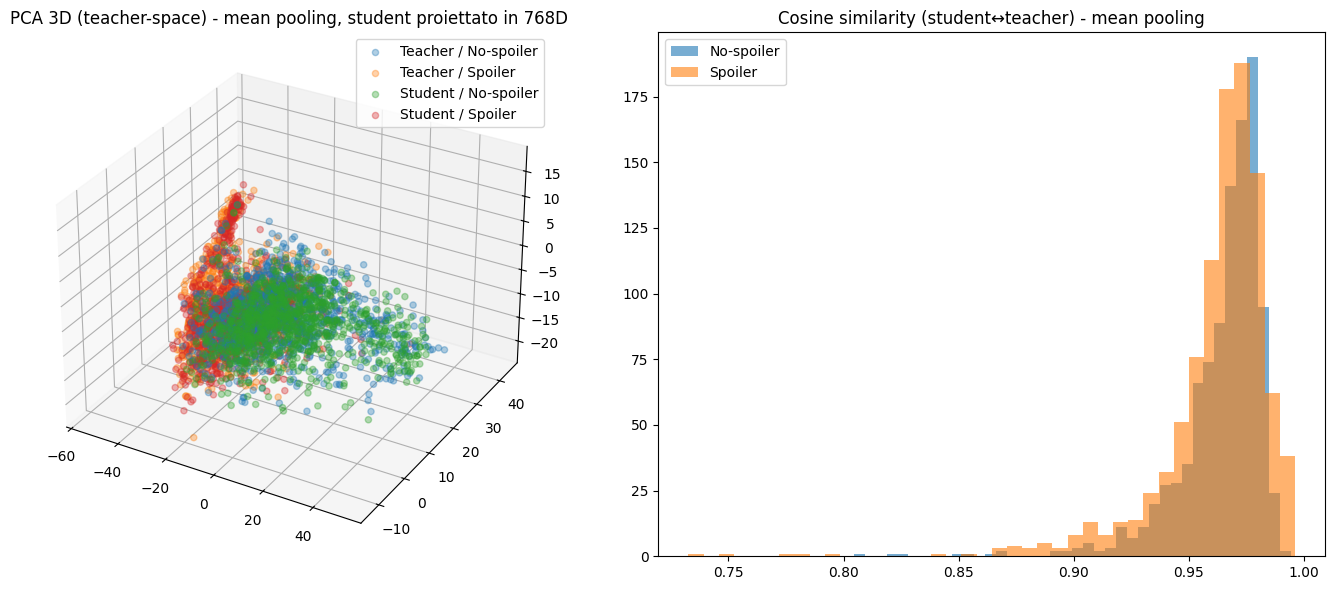

In [8]:
from mpl_toolkits.mplot3d import Axes3D  # noqa

fig = plt.figure(figsize=(14, 6))

ax = fig.add_subplot(121, projection="3d")
# Teacher
ax.scatter(T3[y==0,0], T3[y==0,1], T3[y==0,2], marker="o", alpha=0.35, label="Teacher / No-spoiler")
ax.scatter(T3[y==1,0], T3[y==1,1], T3[y==1,2], marker="o", alpha=0.35, label="Teacher / Spoiler")
# Student
ax.scatter(S3[y==0,0], S3[y==0,1], S3[y==0,2], marker="o", alpha=0.35, label="Student / No-spoiler")
ax.scatter(S3[y==1,0], S3[y==1,1], S3[y==1,2], marker="o", alpha=0.35, label="Student / Spoiler")

ax.set_title("PCA 3D (teacher-space) - mean pooling, student proiettato in 768D")
ax.legend(loc="best")

ax2 = fig.add_subplot(122)
ax2.hist(cos_sim[y==0], bins=40, alpha=0.6, label="No-spoiler")
ax2.hist(cos_sim[y==1], bins=40, alpha=0.6, label="Spoiler")
ax2.set_title("Cosine similarity (student↔teacher) - mean pooling")
ax2.legend()

plt.tight_layout()
plt.show()


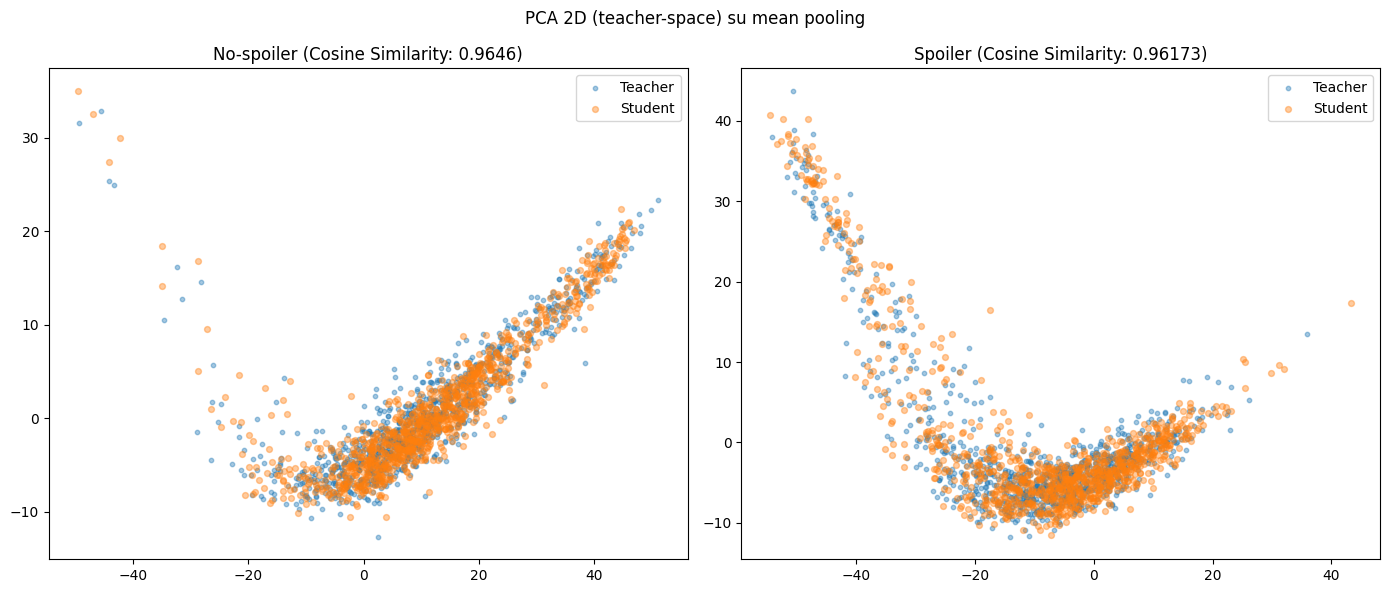

<Figure size 640x480 with 0 Axes>

In [9]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# X teacher-space già costruito: T (N,768), S (N,768), y (N,)
# PCA fit sul teacher
Tz = StandardScaler().fit_transform(T)
pca = PCA(n_components=2, random_state=0).fit(Tz)

T2 = pca.transform(Tz)
S2 = pca.transform(StandardScaler().fit_transform(S))  # meglio: usa lo stesso scaler del teacher!
# -> versione corretta:
scaler = StandardScaler().fit(T)
T2 = pca.fit_transform(scaler.transform(T))
S2 = pca.transform(scaler.transform(S))

ev = pca.explained_variance_ratio_.sum()

fig, axs = plt.subplots(1,2, figsize=(14,6))

for cls, ax in [(0, axs[0]), (1, axs[1])]:
    ax.scatter(T2[y==cls,0], T2[y==cls,1], s=10, alpha=0.4, label="Teacher")
    ax.scatter(S2[y==cls,0], S2[y==cls,1], s=18, alpha=0.4, label="Student")
    ax.set_title((f"No-spoiler (Cosine Similarity: {cos_sim[y==0].mean():.5})" if cls==0 else f"Spoiler (Cosine Similarity: {cos_sim[y==1].mean():.5})"))
    ax.legend()

fig.suptitle(f"PCA 2D (teacher-space) su mean pooling")
plt.tight_layout()
plt.show()
plt.savefig('pca_embeddings.png')

In [10]:
text = "very good film.Apart from Heath ledger,the chasing sequence deserves an Oscar for stunt coordination.I thoroughly enjoyed this. The role of heroine is underplayed excellently,her sudden end leaves one unmoved.It should have been played with more sauciness so that it would have an impact when she dies.In future,let us hope they bring back Ra's Alghul and Bane and make them more mysterious with eastern mysticism.The wit,sarcasm and abrupt violence of Joker in this film acts like cathartic to the urban decay with which one is surrounded.overall,a very satisfying movie which is beginning to feel a lot more better than the graphic novels.I want to go back and see the film again and again.This is the best compliment one can pay."

enc = tokenizer(
    text, 
    add_special_tokens=True, 
    truncation=True,
    max_length =512,
    return_tensors = "pt"
    )
#print("n_subword_tokens =", len(enc["input_ids"]))

enc = {k: v.to(device) for k,v in enc.items()}
tokens = tokenizer.convert_ids_to_tokens(enc["input_ids"][0].tolist())
L = len(tokens)

In [11]:
@torch.no_grad()
def get_attn(model, enc, layer_idx):
    out = model(**enc, output_attentions=True, return_dict=True)
    # HF di solito restituisce già attenzione post-softmax: [B, heads, L, L]
    A = out.attentions[layer_idx][0]          # [heads, L, L]
    A = A.detach().float().cpu().numpy()
    return A

In [12]:
t_layer = 11   # teacher last
s_layer = 3    # student last

A_T = get_attn(teacher, enc, t_layer)         # [hT, L, L]
A_S = get_attn(student, enc, s_layer)   # [hS, L, L]

M_T = A_T.mean(axis=0)  # [L,L]
M_S = A_S.mean(axis=0)

In [13]:
target = "dies"
idxs = [i for i,tok in enumerate(tokens) if tok == target]
if len(idxs) == 0:
    # fallback: cerca sottostringa (per casi wordpiece)
    idxs = [i for i,tok in enumerate(tokens) if target in tok]

center = idxs[0] if idxs else min(20, L//2)
W = 25
a = max(0, center - W)
b = min(L, center + W + 1)

sub_tokens = tokens[a:b]
sub_T = M_T[a:b, a:b]
sub_S = M_S[a:b, a:b]

In [14]:
def flat_cos(X, Y, eps=1e-9):
    x = X.reshape(-1); y = Y.reshape(-1)
    return float((x @ y) / ((np.linalg.norm(x)+eps)*(np.linalg.norm(y)+eps)))

cos = flat_cos(sub_S, sub_T)
mse = float(((sub_S - sub_T)**2).mean())
print(cos, mse)

0.9240966439247131 3.8809717807453126e-05


In [15]:
k = 10
rowT = M_T[center]
rowS = M_S[center]
topT = np.argsort(-rowT)[:k]
topS = np.argsort(-rowS)[:k]
overlap = len(set(topT.tolist()) & set(topS.tolist()))

top = np.argsort(-rowT)[:10]
print([(tokens[i], float(rowT[i])) for i in top])

[('.', 0.05079394951462746), ('.', 0.050793033093214035), ('.', 0.050574202090501785), ('.', 0.050528060644865036), ('.', 0.049713652580976486), ('.', 0.049537479877471924), ('.', 0.0484209768474102), ('.', 0.04804929718375206), ('.', 0.0471438430249691), ('.', 0.04028201103210449)]


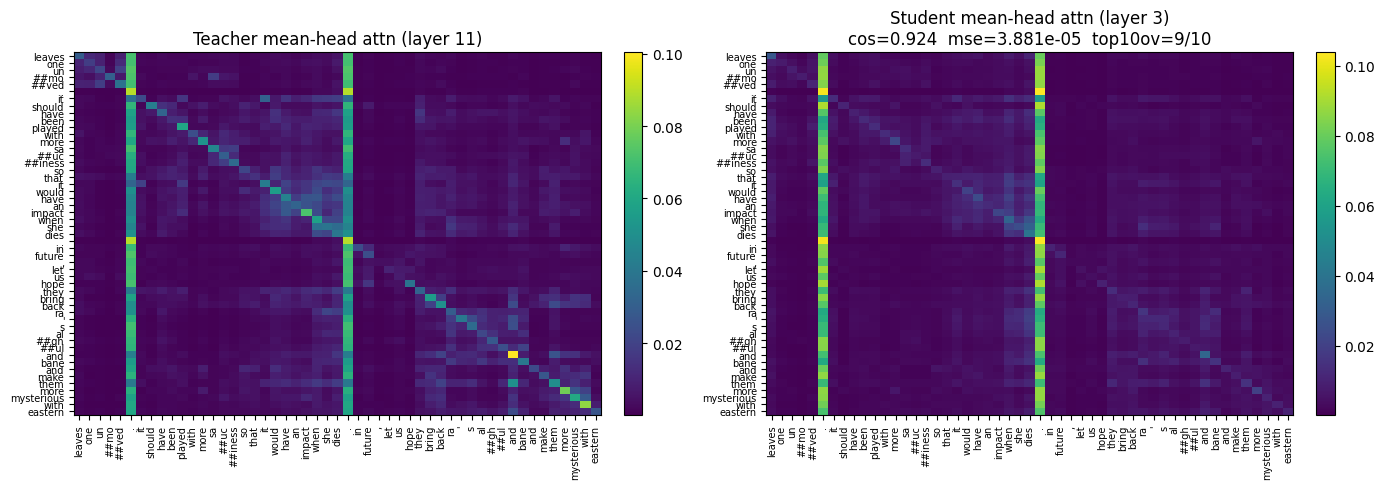

<Figure size 640x480 with 0 Axes>

In [16]:
plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
plt.imshow(sub_T, aspect="auto")
plt.xticks(range(len(sub_tokens)), sub_tokens, rotation=90, fontsize=7)
plt.yticks(range(len(sub_tokens)), sub_tokens, fontsize=7)
plt.title(f"Teacher mean-head attn (layer {t_layer})")
plt.colorbar(fraction=0.046, pad=0.04)

plt.subplot(1,2,2)
plt.imshow(sub_S, aspect="auto")
plt.xticks(range(len(sub_tokens)), sub_tokens, rotation=90, fontsize=7)
plt.yticks(range(len(sub_tokens)), sub_tokens, fontsize=7)
plt.title(f"Student mean-head attn (layer {s_layer})\ncos={cos:.3f}  mse={mse:.4g}  top{k}ov={overlap}/{k}")
plt.colorbar(fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()
plt.savefig('attn_heatmaps.png')

In [ ]:
%pip install transformers_interpret
from transformers_interpret import SequenceClassificationExplainer

# Usa il tuo tokenizer e i modelli già caricati nel notebook
teacher_explainer = SequenceClassificationExplainer(teacher, tokenizer)
student_explainer = SequenceClassificationExplainer(student_core, tokenizer)


# Calcola le attribuzioni
teacher_attributions = teacher_explainer(text)
student_attributions = student_explainer(text)

# La libreria ha un metodo integrato per visualizzare l'output in HTML nel notebook
teacher_explainer.visualize("teacher_saliency.html")
student_explainer.visualize("student_saliency.html")

   ---------------------------------------- 0.0/793.8 kB ? eta -:--:--
   ---------------------------------------- 793.8/793.8 kB 17.1 MB/s  0:00:00
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 1.4/1.4 MB 36.8 MB/s  0:00:00
   ---------------------------------------- 0.0/15.8 MB ? eta -:--:--
   ---------------------------------------- 15.8/15.8 MB 83.1 MB/s  0:00:00

  Attempting uninstall: numpy

    Found existing installation: numpy 2.2.6

    Uninstalling numpy-2.2.6:

   ------------- -------------------------- 2/6 [numpy]
   ------------- -------------------------- 2/6 [numpy]
   ------------- -------------------------- 2/6 [numpy]
   ------------- -------------------------- 2/6 [numpy]
   ------------- -------------------------- 2/6 [numpy]
   ------------- -------------------------- 2/6 [numpy]
      Successfully uninstalled numpy-2.2.6
   ------------- -------------------------- 2/6 [numpy]
   ------------- -

  You can safely remove it manually.
  You can safely remove it manually.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import scipy.stats
import matplotlib.pyplot as plt
import seaborn as sns

def get_mean_cls_entropy(model, test_ds, device, n_samples=500, seed=42):
    """
    Calcola l'entropia media dell'attenzione del token [CLS]
    sfruttando lo stesso stile di iterazione della tua funzione collect_reps.
    """
    model.eval()
    entropies = []
    
    rng = np.random.default_rng(seed)
    # Prendiamo un sottoinsieme per velocizzare (es. 500 o 1000 sample)
    idx = rng.choice(len(test_ds), size=min(n_samples, len(test_ds)), replace=False)
    
    with torch.no_grad():
        for i in idx:
            ex = test_ds[i]
            # Prepariamo i tensori esattamente come fai nel tuo notebook
            input_ids = torch.tensor(ex["input_ids"]).unsqueeze(0).to(device)
            attention_mask = torch.tensor(ex["attention_mask"]).unsqueeze(0).to(device)
            token_type_ids = torch.tensor(ex["token_type_ids"]).unsqueeze(0).to(device) if "token_type_ids" in ex else None
            
            # Forward pass richiedendo esplicitamente le attention maps
            outputs = model(
                input_ids=input_ids, 
                attention_mask=attention_mask, 
                token_type_ids=token_type_ids,
                output_attentions=True,
                return_dict=True
            )
            
            # outputs.attentions è una tupla contenente l'attenzione per ogni layer.
            # Prendiamo l'ultimo layer: [-1]
            last_layer_attn = outputs.attentions[-1] 
            
            # last_layer_attn shape: [1, num_heads, seq_len, seq_len]
            # Facciamo la media sulle attention heads -> shape: [1, seq_len, seq_len]
            mean_heads = last_layer_attn.mean(dim=1)
            
            # Estraiamo l'attenzione del token [CLS] (indice 0) verso tutti gli altri token.
            # shape -> [seq_len]
            cls_attn = mean_heads[0, 0, :]
            
            # Filtriamo i token di padding: ci interessano solo i token effettivi della recensione
            valid_len = attention_mask[0].sum().item()
            valid_attn = cls_attn[:valid_len].cpu().numpy()
            
            # Calcoliamo l'entropia di Shannon (in base e) sulla distribuzione di attenzione
            ent = scipy.stats.entropy(valid_attn)
            entropies.append(ent)
                
    return np.mean(entropies), np.std(entropies)

Entropia Media Teacher: 4.532 ± 0.537
Entropia Media Student: 4.510 ± 0.506


C:\Users\cola0\AppData\Local\Temp\ipykernel_4200\2860603780.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


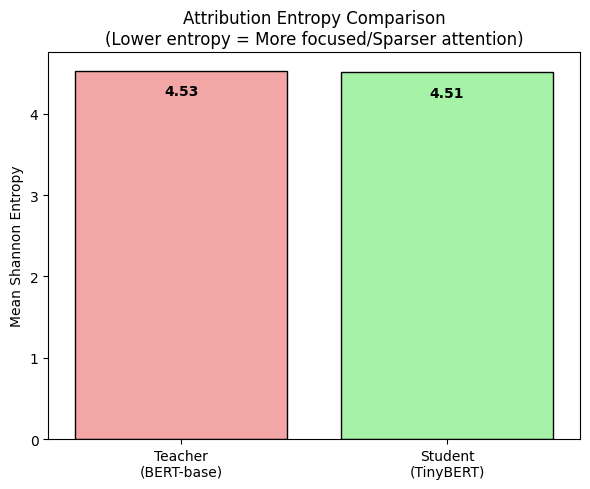

In [ ]:
# Usa il dataset test_balanced che hai già preparato nel notebook
# Usa n_samples=500 o 1000 per calcolarlo in pochi secondi
mean_ent_teacher, std_ent_teacher = get_mean_cls_entropy(teacher, test_balanced, device, n_samples=1000)
mean_ent_student, std_ent_student = get_mean_cls_entropy(student_core, test_balanced, device, n_samples=1000)

print(f"Entropia Media Teacher: {mean_ent_teacher:.3f} ± {std_ent_teacher:.3f}")
print(f"Entropia Media Student: {mean_ent_student:.3f} ± {std_ent_student:.3f}")

# Generazione del grafico (il tuo "Mic Drop" per la presentazione)
plt.figure(figsize=(6, 5))
ax = sns.barplot(
    x=['Teacher\n(BERT-base)', 'Student\n(TinyBERT)'], 
    y=[mean_ent_teacher, mean_ent_student],
    palette=['#FF9999', '#99FF99'],
    edgecolor='black'
)

# Aggiungiamo il testo del valore esatto sulle barre per maggior chiarezza
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, -15), textcoords = 'offset points',
                color='black', fontweight='bold')

plt.title("Attribution Entropy Comparison\n(Lower entropy = More focused/Sparser attention)")
plt.ylabel("Mean Shannon Entropy")
plt.tight_layout()
plt.show()

In [17]:
# === Load final distilled student for interpretability ===
# Per la faithfulness analysis conviene confrontare il teacher fine-tuned
# con lo student finale (phase 2), non con lo student di phase 1 usato per l'alignment.

use_final_student = student_phase2_path.exists()

if use_final_student:
    student_faith = AutoModelForSequenceClassification.from_pretrained(student_phase2_path).to(device).eval()
    print(f"Using final distilled student from: {student_phase2_path}")
else:
    student_faith = student_core.to(device).eval()
    print("WARNING: student_phase2 checkpoint not found. Falling back to current student_core.")

Using final distilled student from: C:\Users\cola0\Desktop\nlp.project-colangelo-2526\checkpoints\tinybert_phase2\checkpoint-13000


In [18]:
import math
from datasets import concatenate_datasets

K_FRACS = [0.05, 0.10, 0.20, 0.30]
FAITH_N_PER_CLASS = 64      # 128 esempi totali: leggero per laptop
TRICKY_MAX_EXAMPLES = 64    # opzionale: subset no-spoiler con cue lessicali
SEED = 42

special_token_ids = {
    tokenizer.cls_token_id,
    tokenizer.sep_token_id,
    tokenizer.pad_token_id,
}
if tokenizer.mask_token_id is None:
    raise ValueError("Tokenizer does not define a [MASK] token, required for token masking.")


def make_balanced_subset(ds, n_per_class=64, seed=42):
    ds0 = ds.filter(lambda x: x["label"] == 0).shuffle(seed=seed).select(range(n_per_class))
    ds1 = ds.filter(lambda x: x["label"] == 1).shuffle(seed=seed).select(range(n_per_class))
    return concatenate_datasets([ds0, ds1]).shuffle(seed=seed)


def example_to_batch(ex, device):
    batch = {
        "input_ids": torch.tensor(ex["input_ids"], dtype=torch.long).unsqueeze(0).to(device),
        "attention_mask": torch.tensor(ex["attention_mask"], dtype=torch.long).unsqueeze(0).to(device),
    }
    if "token_type_ids" in ex:
        batch["token_type_ids"] = torch.tensor(ex["token_type_ids"], dtype=torch.long).unsqueeze(0).to(device)
    return batch


@torch.no_grad()
def forward_logits(model, batch):
    out = model(**batch, return_dict=True)
    return out.logits


def grad_x_input_token_scores(model, batch, target_label):
    model.eval()
    model.zero_grad(set_to_none=True)

    input_ids = batch["input_ids"]
    attention_mask = batch["attention_mask"]
    token_type_ids = batch.get("token_type_ids", None)

    embeds = model.get_input_embeddings()(input_ids).detach().clone()
    embeds.requires_grad_(True)

    out = model(
        inputs_embeds=embeds,
        attention_mask=attention_mask,
        token_type_ids=token_type_ids,
        return_dict=True,
    )

    score = out.logits[0, int(target_label)]
    score.backward()

    grads = embeds.grad[0]                 # [L, H]
    toks  = embeds.detach()[0]             # [L, H]
    token_scores = (grads * toks).sum(dim=-1).abs()   # [L]

    scores = token_scores.detach().float().cpu().numpy()
    ids = input_ids[0].detach().cpu().numpy()
    mask = attention_mask[0].detach().cpu().numpy().astype(bool)

    # rimuovi pad e special tokens dalle posizioni candidabili
    valid_positions = [
        i for i in range(len(ids))
        if mask[i] and int(ids[i]) not in special_token_ids
    ]
    return scores, valid_positions


def mask_topk_tokens(batch, token_scores, valid_positions, frac, mask_token_id):
    masked = {k: v.clone() for k, v in batch.items()}
    if len(valid_positions) == 0:
        return masked, []

    k = max(1, math.ceil(frac * len(valid_positions)))
    ranked_positions = sorted(valid_positions, key=lambda i: float(token_scores[i]), reverse=True)
    top_positions = ranked_positions[:k]

    masked["input_ids"][0, top_positions] = mask_token_id
    return masked, top_positions


def contains_lexical_cue(ex, cue_words=None):
    if cue_words is None:
        cue_words = {"die", "dies", "died", "dead", "kill", "killed", "murder", "murdered"}

    toks = tokenizer.convert_ids_to_tokens(ex["input_ids"])
    normalized = {tok.replace("##", "") for tok in toks}
    return any(c in normalized for c in cue_words)


def build_tricky_subset(ds, max_examples=64, seed=42):
    # no-spoiler con possibili cue lessicali da spoiler
    rng = np.random.default_rng(seed)
    no_spoiler_idx = [i for i in range(len(ds)) if int(ds[i]["label"]) == 0 and contains_lexical_cue(ds[i])]
    if len(no_spoiler_idx) == 0:
        raise ValueError("No tricky examples found with the current lexical cues.")
    rng.shuffle(no_spoiler_idx)
    chosen = no_spoiler_idx[:min(max_examples, len(no_spoiler_idx))]
    return ds.select(chosen)


def evaluate_faithfulness_curve(teacher_model, student_model, ds_subset, k_fracs, device, require_both_correct=True):
    teacher_curve = {k: [] for k in k_fracs}
    student_curve = {k: [] for k in k_fracs}
    kept = 0
    skipped = 0

    for ex in ds_subset:
        batch = example_to_batch(ex, device)
        true_label = int(ex["label"])

        with torch.no_grad():
            t_logits = forward_logits(teacher_model, batch)
            s_logits = forward_logits(student_model, batch)

        t_pred = int(t_logits.argmax(dim=-1).item())
        s_pred = int(s_logits.argmax(dim=-1).item())

        if require_both_correct and (t_pred != true_label or s_pred != true_label):
            skipped += 1
            continue

        # attribution scores
        t_scores, t_valid = grad_x_input_token_scores(teacher_model, batch, target_label=true_label)
        s_scores, s_valid = grad_x_input_token_scores(student_model, batch, target_label=true_label)

        t_base = float(t_logits[0, true_label].item())
        s_base = float(s_logits[0, true_label].item())

        for frac in k_fracs:
            t_masked, _ = mask_topk_tokens(batch, t_scores, t_valid, frac, tokenizer.mask_token_id)
            s_masked, _ = mask_topk_tokens(batch, s_scores, s_valid, frac, tokenizer.mask_token_id)

            with torch.no_grad():
                t_masked_logits = forward_logits(teacher_model, t_masked)
                s_masked_logits = forward_logits(student_model, s_masked)

            t_drop = t_base - float(t_masked_logits[0, true_label].item())
            s_drop = s_base - float(s_masked_logits[0, true_label].item())

            teacher_curve[frac].append(t_drop)
            student_curve[frac].append(s_drop)

        kept += 1

        # conservativo per GPU piccole
        if device == "cuda" and kept % 8 == 0:
            torch.cuda.empty_cache()

    teacher_mean = np.array([np.mean(teacher_curve[k]) if teacher_curve[k] else np.nan for k in k_fracs])
    teacher_std  = np.array([np.std(teacher_curve[k]) if teacher_curve[k] else np.nan for k in k_fracs])

    student_mean = np.array([np.mean(student_curve[k]) if student_curve[k] else np.nan for k in k_fracs])
    student_std  = np.array([np.std(student_curve[k]) if student_curve[k] else np.nan for k in k_fracs])

    stats = {
        "n_total": len(ds_subset),
        "n_used": kept,
        "n_skipped": skipped,
        "teacher_curve_raw": teacher_curve,
        "student_curve_raw": student_curve,
        "teacher_mean": teacher_mean,
        "teacher_std": teacher_std,
        "student_mean": student_mean,
        "student_std": student_std,
        "teacher_aopc": float(np.trapz(teacher_mean, x=k_fracs) / (k_fracs[-1] - k_fracs[0])) if kept > 0 else np.nan,
        "student_aopc": float(np.trapz(student_mean, x=k_fracs) / (k_fracs[-1] - k_fracs[0])) if kept > 0 else np.nan,
    }
    return stats


def plot_faithfulness(stats, k_fracs, title):
    x = np.array(k_fracs) * 100.0

    plt.figure(figsize=(7, 5))
    plt.plot(x, stats["teacher_mean"], marker="o", label="Teacher (BERT-base)")
    plt.plot(x, stats["student_mean"], marker="o", label="Student (TinyBERT)")

    plt.fill_between(
        x,
        stats["teacher_mean"] - stats["teacher_std"],
        stats["teacher_mean"] + stats["teacher_std"],
        alpha=0.15
    )
    plt.fill_between(
        x,
        stats["student_mean"] - stats["student_std"],
        stats["student_mean"] + stats["student_std"],
        alpha=0.15
    )

    plt.xlabel("Top-k masked tokens (%)")
    plt.ylabel("Mean drop in true-class logit")
    plt.title(title)
    plt.xticks(x, [f"{int(v)}%" for v in x])
    plt.legend()
    plt.tight_layout()
    plt.show()


def print_faithfulness_summary(stats, name):
    print(f"=== {name} ===")
    print(f"Used examples: {stats['n_used']} / {stats['n_total']}  (skipped: {stats['n_skipped']})")
    print(f"Teacher AOPC: {stats['teacher_aopc']:.4f}")
    print(f"Student AOPC: {stats['student_aopc']:.4f}")
    print("Teacher mean drops:", {f"{int(k*100)}%": round(float(v), 4) for k, v in zip(K_FRACS, stats["teacher_mean"])})
    print("Student mean drops:", {f"{int(k*100)}%": round(float(v), 4) for k, v in zip(K_FRACS, stats["student_mean"])})

Filter: 100%|██████████| 9925/9925 [00:03<00:00, 2811.24 examples/s]


Dataset({
    features: ['review_id', 'movie_id', 'text', 'label', 'input_ids', 'attention_mask', 'token_type_ids'],
    num_rows: 128
})
=== Balanced subset ===
Used examples: 90 / 128  (skipped: 38)
Teacher AOPC: 0.5617
Student AOPC: 0.3506
Teacher mean drops: {'5%': 0.422, '10%': 0.4971, '20%': 0.5897, '30%': 0.6722}
Student mean drops: {'5%': 0.2034, '10%': 0.2924, '20%': 0.3853, '30%': 0.4422}


C:\Users\cola0\AppData\Local\Temp\ipykernel_17516\4059145990.py:174: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  "teacher_aopc": float(np.trapz(teacher_mean, x=k_fracs) / (k_fracs[-1] - k_fracs[0])) if kept > 0 else np.nan,
C:\Users\cola0\AppData\Local\Temp\ipykernel_17516\4059145990.py:175: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  "student_aopc": float(np.trapz(student_mean, x=k_fracs) / (k_fracs[-1] - k_fracs[0])) if kept > 0 else np.nan,


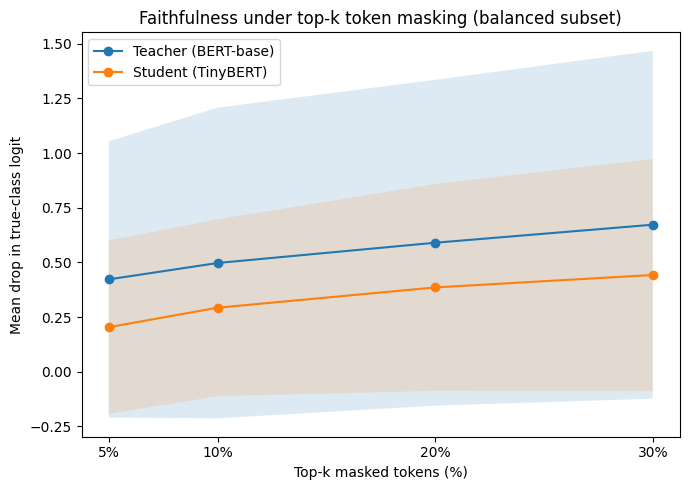

In [19]:
# === Small balanced subset: laptop-friendly default ===
faith_subset = make_balanced_subset(test_ds, n_per_class=FAITH_N_PER_CLASS, seed=SEED)
print(faith_subset)

faith_stats_bal = evaluate_faithfulness_curve(
    teacher_model=teacher,
    student_model=student_faith,
    ds_subset=faith_subset,
    k_fracs=K_FRACS,
    device=device,
    require_both_correct=True,
)

print_faithfulness_summary(faith_stats_bal, "Balanced subset")
plot_faithfulness(
    faith_stats_bal,
    K_FRACS,
    title="Faithfulness under top-k token masking (balanced subset)"
)

Dataset({
    features: ['review_id', 'movie_id', 'text', 'label', 'input_ids', 'attention_mask', 'token_type_ids'],
    num_rows: 64
})
=== Tricky no-spoiler subset ===
Used examples: 33 / 64  (skipped: 31)
Teacher AOPC: 0.0937
Student AOPC: 0.3604
Teacher mean drops: {'5%': 0.0349, '10%': 0.0982, '20%': 0.0609, '30%': 0.1817}
Student mean drops: {'5%': 0.1485, '10%': 0.2683, '20%': 0.4121, '30%': 0.5009}


C:\Users\cola0\AppData\Local\Temp\ipykernel_17516\4059145990.py:174: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  "teacher_aopc": float(np.trapz(teacher_mean, x=k_fracs) / (k_fracs[-1] - k_fracs[0])) if kept > 0 else np.nan,
C:\Users\cola0\AppData\Local\Temp\ipykernel_17516\4059145990.py:175: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  "student_aopc": float(np.trapz(student_mean, x=k_fracs) / (k_fracs[-1] - k_fracs[0])) if kept > 0 else np.nan,


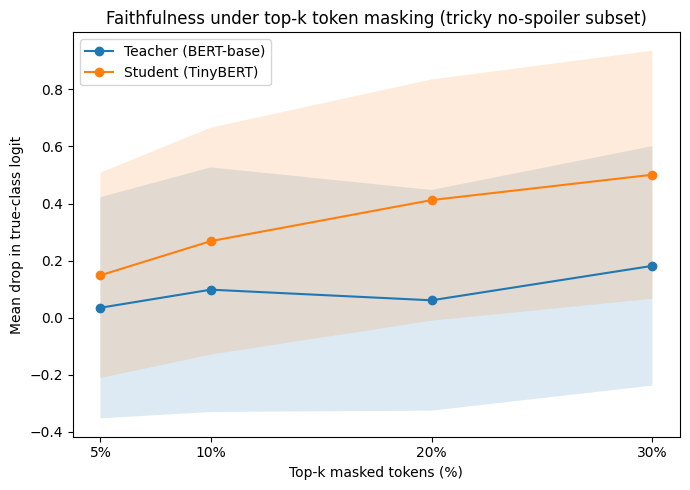

In [20]:
# === Optional: tricky no-spoiler subset with spoiler-like lexical cues ===
# Utile se vuoi una figura aggiuntiva per il report o per la presentazione.
# Se vuoi restare minimale, puoi saltare questa cella.

tricky_subset = build_tricky_subset(test_ds, max_examples=TRICKY_MAX_EXAMPLES, seed=SEED)
print(tricky_subset)

faith_stats_tricky = evaluate_faithfulness_curve(
    teacher_model=teacher,
    student_model=student_faith,
    ds_subset=tricky_subset,
    k_fracs=K_FRACS,
    device=device,
    require_both_correct=True,
)

print_faithfulness_summary(faith_stats_tricky, "Tricky no-spoiler subset")
plot_faithfulness(
    faith_stats_tricky,
    K_FRACS,
    title="Faithfulness under top-k token masking (tricky no-spoiler subset)"
)

Teacher entropy shape: (1000, 12)
Student entropy shape: (1000, 4)


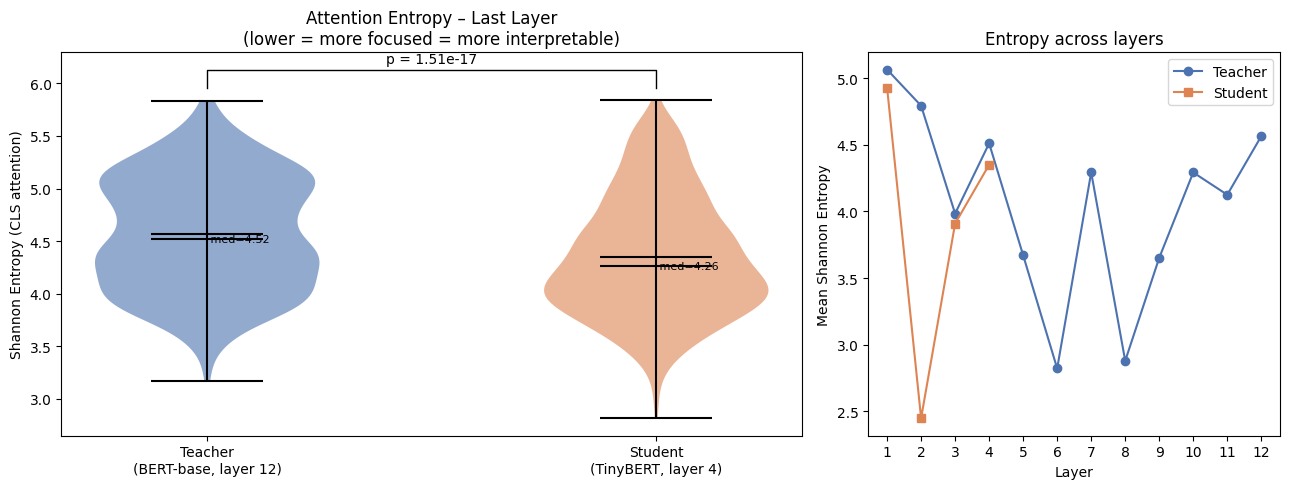


Teacher last-layer entropy: 4.565 ± 0.550  (median 4.523)
Student last-layer entropy: 4.350 ± 0.570  (median 4.264)
Mann-Whitney U test: U=610101.0, p=1.51e-17


In [21]:
# ============================================================
# CELL A: Funzione per raccogliere entropia CLS per-sample, per-layer
# ============================================================
import scipy.stats
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch

def collect_cls_entropy_per_layer(model, test_ds, device, n_samples=500, seed=42):
    """
    Per ogni sample, per ogni layer, calcola l'entropia di Shannon
    della distribuzione di attenzione del token [CLS] (media sulle head).
    
    Ritorna: np.array di shape (n_samples, n_layers)
    """
    model.eval()
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(test_ds), size=min(n_samples, len(test_ds)), replace=False)
    
    all_entropies = []  # lista di array (n_layers,)
    
    with torch.no_grad():
        for i in idx:
            ex = test_ds[i]
            input_ids = torch.tensor(ex["input_ids"]).unsqueeze(0).to(device)
            attention_mask = torch.tensor(ex["attention_mask"]).unsqueeze(0).to(device)
            token_type_ids = (
                torch.tensor(ex["token_type_ids"]).unsqueeze(0).to(device)
                if "token_type_ids" in ex else None
            )
            
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                token_type_ids=token_type_ids,
                output_attentions=True,
                return_dict=True,
            )
            
            valid_len = int(attention_mask[0].sum().item())
            sample_ent = []
            
            for layer_attn in outputs.attentions:
                # layer_attn: [1, heads, L, L]
                mean_heads = layer_attn.mean(dim=1)       # [1, L, L]
                cls_attn = mean_heads[0, 0, :valid_len]   # [valid_len]
                cls_attn = cls_attn.float().cpu().numpy()
                # scipy.stats.entropy gestisce già la normalizzazione se la somma != 1,
                # ma l'attenzione post-softmax dovrebbe già sommare a ~1 sui token validi.
                # Aggiungiamo eps per sicurezza numerica.
                cls_attn = cls_attn + 1e-12
                cls_attn = cls_attn / cls_attn.sum()
                ent = scipy.stats.entropy(cls_attn)
                sample_ent.append(ent)
            
            all_entropies.append(sample_ent)
    
    return np.array(all_entropies)  # (n_samples, n_layers)


# ============================================================
# CELL B: Calcolo su test_balanced (già definito nel notebook)
# ============================================================
N_ENTROPY_SAMPLES = 1000

# Teacher: 12 layer
teacher_ent = collect_cls_entropy_per_layer(teacher, test_balanced, device, n_samples=N_ENTROPY_SAMPLES)
print(f"Teacher entropy shape: {teacher_ent.shape}")  # (1000, 12)

# Student phase 2 (finale) - usa student_faith se caricato, altrimenti student_core
student_model_for_ent = student_faith if 'student_faith' in dir() else student_core
student_ent = collect_cls_entropy_per_layer(student_model_for_ent, test_balanced, device, n_samples=N_ENTROPY_SAMPLES)
print(f"Student entropy shape: {student_ent.shape}")  # (1000, 4)


# ============================================================
# CELL C: Plot - Confronto ultimo layer (violin + test statistico)
# ============================================================
from scipy.stats import mannwhitneyu

# Ultimo layer di ciascun modello
t_last = teacher_ent[:, -1]   # entropia ultimo layer teacher (12° layer)
s_last = student_ent[:, -1]   # entropia ultimo layer student (4° layer)

stat, pval = mannwhitneyu(t_last, s_last, alternative='two-sided')

fig, axes = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={'width_ratios': [1.8, 1]})

# --- Pannello sinistro: violin plot ---
ax = axes[0]
data_violin = [t_last, s_last]
parts = ax.violinplot(data_violin, positions=[0, 1], showmeans=True, showmedians=True)

# Colora i violini
colors = ['#4C72B0', '#DD8452']
for pc, color in zip(parts['bodies'], colors):
    pc.set_facecolor(color)
    pc.set_alpha(0.6)
for key in ['cmeans', 'cmedians', 'cbars', 'cmins', 'cmaxes']:
    parts[key].set_color('black')

ax.set_xticks([0, 1])
ax.set_xticklabels(['Teacher\n(BERT-base, layer 12)', 'Student\n(TinyBERT, layer 4)'])
ax.set_ylabel('Shannon Entropy (CLS attention)')
ax.set_title('Attention Entropy – Last Layer\n(lower = more focused = more interpretable)')

# Annotazione significatività
y_max = max(t_last.max(), s_last.max())
sig_label = f"p = {pval:.2e}" if pval < 0.001 else f"p = {pval:.4f}"
ax.plot([0, 0, 1, 1], [y_max*1.02, y_max*1.05, y_max*1.05, y_max*1.02], 'k-', lw=1)
ax.text(0.5, y_max*1.06, sig_label, ha='center', fontsize=10)

# Mediane + medie come testo
ax.text(0, np.median(t_last), f" med={np.median(t_last):.2f}", fontsize=8, va='center')
ax.text(1, np.median(s_last), f" med={np.median(s_last):.2f}", fontsize=8, va='center')

# --- Pannello destro: entropia media per layer ---
ax2 = axes[1]
teacher_layer_means = teacher_ent.mean(axis=0)
student_layer_means = student_ent.mean(axis=0)

ax2.plot(range(1, len(teacher_layer_means)+1), teacher_layer_means, 'o-', color=colors[0], label='Teacher')
ax2.plot(range(1, len(student_layer_means)+1), student_layer_means, 's-', color=colors[1], label='Student')
ax2.set_xlabel('Layer')
ax2.set_ylabel('Mean Shannon Entropy')
ax2.set_title('Entropy across layers')
ax2.legend()
ax2.set_xticks(range(1, max(len(teacher_layer_means), len(student_layer_means))+1))

plt.tight_layout()
plt.savefig('attention_entropy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Stampa riassuntiva
print(f"\n{'='*50}")
print(f"Teacher last-layer entropy: {t_last.mean():.3f} ± {t_last.std():.3f}  (median {np.median(t_last):.3f})")
print(f"Student last-layer entropy: {s_last.mean():.3f} ± {s_last.std():.3f}  (median {np.median(s_last):.3f})")
print(f"Mann-Whitney U test: U={stat:.1f}, p={pval:.2e}")
print(f"{'='*50}")

Note: you may need to restart the kernel to use updated packages.
Teacher prediction:
  pred = 1 (Spoiler)
  probs = [0.26803598 0.73196405]
  IG target = 1 (Spoiler)
  convergence delta = 0.125434

Student prediction:
  pred = 1 (Spoiler)
  probs = [0.42901766 0.57098234]
  IG target = 1 (Spoiler)
  convergence delta = -0.000226


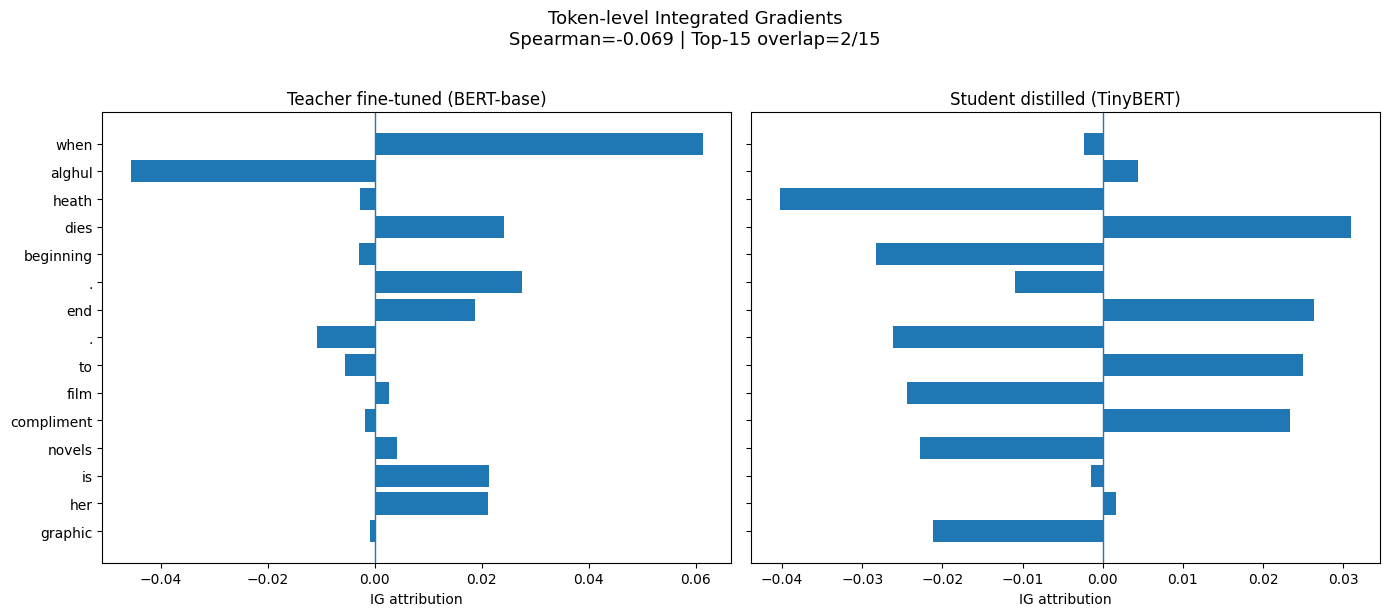

In [23]:
# ============================================================
# Integrated Gradients: token-level attribution
# Teacher fine-tuned vs final distilled student
# Incolla questa cella DOPO la tua cella 20
# ============================================================

%pip install -q captum

import numpy as np
import torch
import matplotlib.pyplot as plt
from captum.attr import LayerIntegratedGradients
from scipy.stats import spearmanr

LABEL_NAMES = {0: "No spoiler", 1: "Spoiler"}

# ============================================================
# Tu compila solo questa variabile
# ============================================================
review_text = "very good film.Apart from Heath ledger,the chasing sequence deserves an Oscar for stunt coordination.I thoroughly enjoyed this. The role of heroine is underplayed excellently,her sudden end leaves one unmoved.It should have been played with more sauciness so that it would have an impact when she dies.In future,let us hope they bring back Ra's Alghul and Bane and make them more mysterious with eastern mysticism.The wit,sarcasm and abrupt violence of Joker in this film acts like cathartic to the urban decay with which one is surrounded.overall,a very satisfying movie which is beginning to feel a lot more better than the graphic novels.I want to go back and see the film again and again.This is the best compliment one can pay.".strip()

# Lascia None per usare automaticamente la predizione del teacher
# Metti 1 se vuoi forzare attribution toward spoiler
# Metti 0 se vuoi forzare attribution toward no-spoiler
TARGET_LABEL = None

# Parametri leggeri per GTX 1650
N_STEPS = 64
INTERNAL_BATCH_SIZE = 4
TOP_K = 15

HEAD_TOKENS = 128
TAIL_TOKENS = 382
MAX_LEN = 512


def get_model_device(model):
    return next(model.parameters()).device


def encode_head_tail(text, tokenizer, max_len=512, head_tokens=128, tail_tokens=382, device=None):
    """
    Replica la tua logica di preprocessing:
    [CLS] + first 128 tokens + last 382 tokens + [SEP]
    se la review eccede la lunghezza massima.
    Niente padding qui: per 1 sample è più leggero.
    """
    toks = tokenizer.tokenize(text)
    max_content_len = max_len - 2

    if len(toks) > max_content_len:
        toks = toks[:head_tokens] + toks[-tail_tokens:]
        toks = toks[:max_content_len]

    final_tokens = [tokenizer.cls_token] + toks + [tokenizer.sep_token]
    input_ids = tokenizer.convert_tokens_to_ids(final_tokens)
    attention_mask = [1] * len(input_ids)

    encoded = {
        "input_ids": torch.tensor([input_ids], dtype=torch.long, device=device),
        "attention_mask": torch.tensor([attention_mask], dtype=torch.long, device=device),
    }

    if "token_type_ids" in tokenizer.model_input_names:
        encoded["token_type_ids"] = torch.zeros((1, len(input_ids)), dtype=torch.long, device=device)

    return encoded, final_tokens


def make_baseline_input_ids(input_ids, tokenizer):
    """
    Baseline per IG:
    tutto PAD, ma mantieni [CLS] e [SEP] nelle posizioni corrette.
    """
    baseline = torch.full_like(input_ids, tokenizer.pad_token_id)
    baseline[:, 0] = tokenizer.cls_token_id
    baseline[:, -1] = tokenizer.sep_token_id
    return baseline


def predict_label_and_probs(model, batch):
    model.eval()
    with torch.no_grad():
        out = model(**batch, return_dict=True)
        probs = torch.softmax(out.logits, dim=-1)[0].detach().cpu().numpy()
        pred = int(np.argmax(probs))
    return pred, probs


def make_forward_func(model):
    def forward_func(input_ids, attention_mask, token_type_ids=None):
        out = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
            return_dict=True,
        )
        return out.logits
    return forward_func


def compute_ig_token_scores(model, tokenizer, text, target_label=None, n_steps=16, internal_batch_size=2):
    model.eval()
    device = get_model_device(model)

    batch, tokens = encode_head_tail(
        text,
        tokenizer,
        max_len=MAX_LEN,
        head_tokens=HEAD_TOKENS,
        tail_tokens=TAIL_TOKENS,
        device=device,
    )

    pred, probs = predict_label_and_probs(model, batch)

    if target_label is None:
        target_label = pred

    forward_func = make_forward_func(model)
    lig = LayerIntegratedGradients(forward_func, model.get_input_embeddings())

    baseline_ids = make_baseline_input_ids(batch["input_ids"], tokenizer)
    token_type_ids = batch.get("token_type_ids", None)

    attributions, delta = lig.attribute(
        inputs=batch["input_ids"],
        baselines=baseline_ids,
        additional_forward_args=(batch["attention_mask"], token_type_ids),
        target=int(target_label),
        n_steps=n_steps,
        internal_batch_size=internal_batch_size,
        return_convergence_delta=True,
    )

    # [1, L, H] -> [L]
    scores = attributions.sum(dim=-1).squeeze(0).detach().cpu().numpy()

    # normalizzazione per confronto visivo tra modelli
    denom = np.sum(np.abs(scores)) + 1e-12
    scores = scores / denom

    return {
        "tokens": tokens,
        "scores": scores,
        "pred": pred,
        "probs": probs,
        "target_label": int(target_label),
        "delta": float(delta.detach().cpu().item()) if torch.is_tensor(delta) else float(delta),
    }


def merge_wordpieces(tokens, scores):
    """
    Unisce i token BERT tipo:
    ['the', 'hero', 'die', '##s'] -> ['the', 'hero', 'dies']
    Somma i punteggi IG dei subword.
    """
    merged_tokens = []
    merged_scores = []

    special = {"[CLS]", "[SEP]", "[PAD]"}

    for tok, sc in zip(tokens, scores):
        if tok in special:
            continue

        if tok.startswith("##") and len(merged_tokens) > 0:
            merged_tokens[-1] = merged_tokens[-1] + tok[2:]
            merged_scores[-1] += sc
        else:
            merged_tokens.append(tok)
            merged_scores.append(sc)

    return merged_tokens, np.array(merged_scores, dtype=np.float32)


def comparison_stats(scores_a, scores_b, top_k=15):
    rho, _ = spearmanr(scores_a, scores_b)

    top_a = set(np.argsort(-np.abs(scores_a))[:top_k].tolist())
    top_b = set(np.argsort(-np.abs(scores_b))[:top_k].tolist())
    overlap = len(top_a & top_b)

    return float(rho), int(overlap)


def plot_teacher_student_ig(tokens, scores_teacher, scores_student, teacher_name="Teacher", student_name="Student", top_k=15):
    # selezione token più importanti in almeno uno dei due modelli
    combined = np.maximum(np.abs(scores_teacher), np.abs(scores_student))
    idx = np.argsort(-combined)[:top_k]

    # per avere il più importante in alto nel barplot
    idx = idx[::-1]

    toks = [tokens[i] for i in idx]
    tvals = scores_teacher[idx]
    svals = scores_student[idx]

    rho, overlap = comparison_stats(scores_teacher, scores_student, top_k=top_k)

    fig, axes = plt.subplots(1, 2, figsize=(14, max(6, top_k * 0.35)), sharey=True)

    axes[0].barh(range(len(toks)), tvals)
    axes[0].axvline(0, linewidth=1)
    axes[0].set_yticks(range(len(toks)))
    axes[0].set_yticklabels(toks, fontsize=10)
    axes[0].set_title(teacher_name)
    axes[0].set_xlabel("IG attribution")

    axes[1].barh(range(len(toks)), svals)
    axes[1].axvline(0, linewidth=1)
    axes[1].set_yticks(range(len(toks)))
    axes[1].set_yticklabels(toks, fontsize=10)
    axes[1].set_title(student_name)
    axes[1].set_xlabel("IG attribution")

    fig.suptitle(
        f"Token-level Integrated Gradients\n"
        f"Spearman={rho:.3f} | Top-{top_k} overlap={overlap}/{top_k}",
        y=1.02,
        fontsize=13
    )

    plt.tight_layout()
    plt.show()


# ============================================================
# RUN
# ============================================================

# Teacher
teacher_res = compute_ig_token_scores(
    model=teacher,
    tokenizer=tokenizer,
    text=review_text,
    target_label=TARGET_LABEL,
    n_steps=N_STEPS,
    internal_batch_size=INTERNAL_BATCH_SIZE,
)

# Student finale distillato
student_res = compute_ig_token_scores(
    model=student_faith,
    tokenizer=tokenizer,
    text=review_text,
    target_label=teacher_res["target_label"],  # stesso target del teacher per confronto coerente
    n_steps=N_STEPS,
    internal_batch_size=INTERNAL_BATCH_SIZE,
)

print("Teacher prediction:")
print(f"  pred = {teacher_res['pred']} ({LABEL_NAMES[teacher_res['pred']]})")
print(f"  probs = {teacher_res['probs']}")
print(f"  IG target = {teacher_res['target_label']} ({LABEL_NAMES[teacher_res['target_label']]})")
print(f"  convergence delta = {teacher_res['delta']:.6f}")

print("\nStudent prediction:")
print(f"  pred = {student_res['pred']} ({LABEL_NAMES[student_res['pred']]})")
print(f"  probs = {student_res['probs']}")
print(f"  IG target = {student_res['target_label']} ({LABEL_NAMES[student_res['target_label']]})")
print(f"  convergence delta = {student_res['delta']:.6f}")

if teacher_res["pred"] != student_res["pred"]:
    print("\nWARNING: teacher e student non predicono la stessa classe su questa review.")
    print("Il confronto resta possibile, ma è meglio scegliere un esempio dove coincidono.")

# merge wordpieces
merged_tokens_t, merged_scores_t = merge_wordpieces(teacher_res["tokens"], teacher_res["scores"])
merged_tokens_s, merged_scores_s = merge_wordpieces(student_res["tokens"], student_res["scores"])

assert merged_tokens_t == merged_tokens_s, "Token merge mismatch tra teacher e student."

plot_teacher_student_ig(
    tokens=merged_tokens_t,
    scores_teacher=merged_scores_t,
    scores_student=merged_scores_s,
    teacher_name="Teacher fine-tuned (BERT-base)",
    student_name="Student distilled (TinyBERT)",
    top_k=TOP_K
)